In [29]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np

# 1. Target URL & Headers
url = "https://www.worldometers.info/world-population/"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

print("Fetching webpage...")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    print("Page fetched successfully!")
else:
    print(f"Failed to fetch page. Status code: {response.status_code}")

Fetching webpage...
Page fetched successfully!


In [37]:
soup = BeautifulSoup(response.text,'html.parser')
table = soup.find('table', class_='datatable')
#print head

header = []
thead = table.find('thead')
for th in thead.find('tr').find_all('th'):
    header.append(th.text.strip())


#print body
tbody = table.find('tbody')
trows = tbody.find_all('tr')

data = []

for row in trows:
    cells = row.find_all('td')
    if not cells:
        continue
    row_text = [cell.text.strip() for cell in cells]
    data.append(row_text)

df = pd.DataFrame(data,columns=header)
print(df)

   Year (July 1)     Population Yearly % Change Yearly Change Median Age  \
0           2026  8,300,678,395           0.84%    69,065,325       31.1   
1           2025  8,231,613,070           0.85%    69,640,498       30.9   
2           2024  8,161,972,572           0.87%    70,237,642       30.6   
3           2023  8,091,734,930           0.88%    70,327,738       30.4   
4           2022  8,021,407,192           0.84%    66,958,801       30.1   
5           2021  7,954,448,391           0.86%    67,447,099       29.8   
6           2020  7,887,001,292           1.09%    83,301,884       29.6   
7           2015  7,470,491,872           1.25%    89,751,945       28.3   
8           2010  7,021,732,148           1.29%    86,952,403       27.2   
9           2005  6,586,970,132           1.31%    83,053,428       26.1   
10          2000  6,171,702,993           1.39%    82,564,802       25.1   
11          1995  5,758,878,982           1.57%    86,215,174         24   
12          

In [41]:
#cleaning the data
cols_to_clean = ['Population' ,'Yearly % Change' ,'Yearly Change', 'Median Age','Fertility Rate', 'Density (P/KmÂ²)']

df[cols_to_clean] = (df[cols_to_clean].replace(r'[\$,%]', "", regex=True).astype(float))

In [42]:
df.head()

,Year (July 1),Population,Yearly % Change,Yearly Change,Median Age,Fertility Rate,Density (P/KmÂ²)
0,2026,8.300678e+09,0.84,69065325.0,31.1,2.23,56.0
1,2025,8.231613e+09,0.85,69640498.0,30.9,2.24,55.0
2,2024,8.161973e+09,0.87,70237642.0,30.6,2.25,55.0
3,2023,8.091735e+09,0.88,70327738.0,30.4,2.25,54.0
4,2022,8.021407e+09,0.84,66958801.0,30.1,2.27,54.0


In [43]:
df.describe()  # Gives mean, std, min, max, and quantiles for numeric columns

,Population,Yearly % Change,Yearly Change,Median Age,Fertility Rate,Density (P/KmÂ²)
count,2.000000e+01,20.000000,2.000000e+01,20.000000,20.000000,20.000000
mean,6.057931e+09,1.419000,7.462294e+07,25.735000,3.175500,40.600000
std,1.975863e+09,0.467185,1.137402e+07,4.079896,1.035331,13.303739
min,2.740214e+09,0.840000,4.942419e+07,20.300000,2.230000,18.000000
25%,4.353388e+09,0.877500,6.866077e+07,21.725000,2.285000,29.250000
50%,6.379337e+09,1.350000,7.362016e+07,25.600000,2.690000,42.500000
75%,7.971188e+09,1.850000,8.354327e+07,29.875000,3.825000,53.250000
max,8.300678e+09,2.070000,9.177193e+07,31.100000,5.070000,56.000000


In [50]:
# Example: Top 5 categories by total revenue/population
df.groupby('Median Age')['Yearly Change'].sum().sort_values(ascending=False).head(5)

Median Age
21.5    130425612.0
22.9     91771929.0
28.3     89751945.0
27.2     86952403.0
24.0     86215174.0
Name: Yearly Change, dtype: float64

In [49]:
# Top 10 highest values
top_10 = df.nlargest(10, 'Population')
print(top_10)

  Year (July 1)    Population  Yearly % Change  Yearly Change  Median Age  \
0          2026  8.300678e+09             0.84     69065325.0        31.1   
1          2025  8.231613e+09             0.85     69640498.0        30.9   
2          2024  8.161973e+09             0.87     70237642.0        30.6   
3          2023  8.091735e+09             0.88     70327738.0        30.4   
4          2022  8.021407e+09             0.84     66958801.0        30.1   
5          2021  7.954448e+09             0.86     67447099.0        29.8   
6          2020  7.887001e+09             1.09     83301884.0        29.6   
7          2015  7.470492e+09             1.25     89751945.0        28.3   
8          2010  7.021732e+09             1.29     86952403.0        27.2   
9          2005  6.586970e+09             1.31     83053428.0        26.1   

   Fertility Rate  Density (P/KmÂ²)  
0            2.23              56.0  
1            2.24              55.0  
2            2.25              55.0  


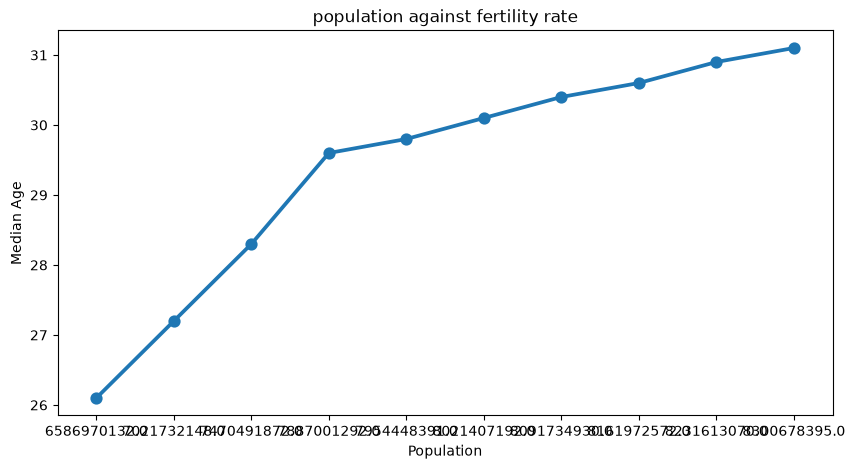

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Top 10 Bar Chart
plt.figure(figsize=(10, 5))
sns.pointplot(data=top_10, x='Population', y='Median Age')
plt.title('population against fertility rate')
plt.show()

In [59]:
df.to_csv("worldometers_population.csv", index=False)